# 04C — Hybrid party-text and institutional validation

本 Notebook 检验一个混合模型：

- 各政党拥有独立的 Word TF-IDF 文本权重；
- 政党角色、政府背书及两者的组合在所有政党之间共享；
- motion type、policy domain 和时间等扩展信息通过 ablation test 判断是否有帮助；
- 04B 的四个独立 `party_heads_word` 会作为直接基线重新计算；
- 默认只使用 Validation，不查看 Test 指标。

核心目标是判断 04B 的 Labour 瓶颈是否来自政党角色变化，而不是立即把问题归因于 P2。

In [1]:
# 导入本 Notebook 需要的库。
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET = 'target_binary_support'
TEXT_COLUMN = 'model_text'

# 第一次运行必须保持 False，避免模型开发阶段查看 Test。
RUN_FINAL_TEST = False

# 延续 04B 的验收标准，避免看到结果后再降低门槛。
MIN_VALIDATION_MACRO_F1 = 0.72
MIN_IMPROVEMENT_OVER_PARTY_BASELINE = 0.05
MIN_WORST_PARTY_MACRO_F1 = 0.60

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'processed' / 'model_v2'
OUTPUT_DIR = DATA_DIR / 'baseline_hybrid'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'model_train_v2.csv'
VALIDATION_PATH = DATA_DIR / 'model_validation_v2.csv'
TEST_PATH = DATA_DIR / 'model_test_v2.csv'

print('Data directory:', DATA_DIR)
print('RUN_FINAL_TEST:', RUN_FINAL_TEST)

Data directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/model_v2
RUN_FINAL_TEST: False


## 1. Load data and protect the Test split

只展示 Train 和 Validation 的标签分布。Test 仅用于检查文件结构和议案重叠；在开关关闭时不会显示标签统计或进行预测。

In [2]:
# 读取数据并建立连续索引，方便稀疏矩阵按行切片。
train = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
validation = pd.read_csv(VALIDATION_PATH).reset_index(drop=True)
test = pd.read_csv(TEST_PATH).reset_index(drop=True)

for frame in (train, validation, test):
    frame[TARGET] = frame[TARGET].astype(int)
    frame[TEXT_COLUMN] = frame[TEXT_COLUMN].fillna('').astype(str)
    frame['motion_date'] = pd.to_datetime(frame['motion_date'])

# 同一个 division 不能跨数据集出现。
assert train['row_id'].is_unique
assert validation['row_id'].is_unique
assert test['row_id'].is_unique
assert not set(train['division_key']) & set(validation['division_key'])
assert not set(train['division_key']) & set(test['division_key'])
assert not set(validation['division_key']) & set(test['division_key'])

development_overview = pd.DataFrame({
    'rows': [len(train), len(validation)],
    'divisions': [
        train['division_key'].nunique(),
        validation['division_key'].nunique(),
    ],
    'support_rate': [train[TARGET].mean(), validation[TARGET].mean()],
    'start_date': [train['motion_date'].min(), validation['motion_date'].min()],
    'end_date': [train['motion_date'].max(), validation['motion_date'].max()],
}, index=['train', 'validation'])
display(development_overview.round(3))

party_audit = (
    pd.concat([
        train.assign(split='train'),
        validation.assign(split='validation'),
    ], ignore_index=True)
    .groupby(['split', 'party'])[TARGET]
    .agg(rows='size', support_rate='mean', label_count='nunique')
    .reset_index()
)
assert party_audit['label_count'].eq(2).all(), '某个政党缺少一个二分类标签。'
display(party_audit.round(3))

,rows,divisions,support_rate,start_date,end_date
train,2822,770,0.569,2016-01-06,2023-12-13
validation,570,169,0.591,2024-01-09,2024-12-17


,split,party,rows,support_rate,label_count
0,train,conservative,769,0.494,2
1,train,green,663,0.585,2
2,train,labour,700,0.596,2
3,train,liberal-democrat,690,0.610,2
4,validation,conservative,159,0.358,2
5,validation,green,135,0.696,2
6,validation,labour,151,0.629,2
7,validation,liberal-democrat,125,0.728,2


## 2. Construct institutional features

`role_backing_interaction` 明确表示“当前政党角色 × 被表决对象是否由政府背书”。它不使用实际投票结果。

例如：

- `governing_party__government_backed`
- `main_opposition__government_backed`
- `governing_party__not_government_backed`
- `smaller_opposition__unknown`

该字段让同一套制度规律可以跨政党共享。

In [3]:
def add_institutional_features(frame):
    # 复制数据，避免修改原始 DataFrame。
    result = frame.copy()

    # 把政府背书状态显式转成三个类别：是、否、未知。
    known = result['government_backing_known'].fillna(0).astype(int).eq(1)
    backed = result['final_object_government_backed'].fillna(0).astype(int).eq(1)
    result['government_backing_status'] = np.select(
        [~known, backed],
        ['unknown', 'government_backed'],
        default='not_government_backed',
    )

    # 组合政党角色与政府背书，形成可共享的制度关系。
    result['role_backing_interaction'] = (
        result['party_role'].fillna('unknown').astype(str)
        + '__'
        + result['government_backing_status'].astype(str)
    )

    # 用 2024 年英国大选前后做诊断，不作为模型特征。
    result['validation_era'] = np.where(
        result['motion_date'] < pd.Timestamp('2024-07-05'),
        'pre_2024_election',
        'post_2024_election',
    )
    return result


train = add_institutional_features(train)
validation = add_institutional_features(validation)
test = add_institutional_features(test)

display(
    train[
        ['party', 'party_role', 'government_backing_status',
         'role_backing_interaction']
    ].drop_duplicates().sort_values(['party', 'role_backing_interaction'])
)

,party,party_role,government_backing_status,role_backing_interaction
2315,conservative,governing_party,government_backed,governing_party__government_backed
0,conservative,governing_party,unknown,governing_party__unknown
2440,green,smaller_opposition,government_backed,smaller_opposition__government_backed
1,green,smaller_opposition,unknown,smaller_opposition__unknown
2535,labour,main_opposition,government_backed,main_opposition__government_backed
2,labour,main_opposition,unknown,main_opposition__unknown
3,liberal-democrat,smaller_opposition,unknown,smaller_opposition__unknown


## 3. Define leakage-safe feature groups

`CORE` 只包含政党身份与制度关系；`EXTENDED` 再加入议案类型、政策领域和时间。通过比较两组模型判断扩展字段究竟增加信号还是噪声。

In [4]:
# 核心结构特征用于共享角色与政府背书规律。
CORE_CATEGORICAL = [
    'party',
    'party_role',
    'government_backing_status',
    'role_backing_interaction',
    'party_object_alignment',
]

CORE_NUMERIC = [
    'government_backing_known',
    'final_object_government_backed',
    'is_governing_party',
    'is_main_opposition',
    'is_opposition_day',
]

# 扩展结构特征用于检验政策领域、议案类型和时间是否有额外帮助。
EXTENDED_CATEGORICAL = CORE_CATEGORICAL + [
    'motion_type',
    'motion_family',
    'policy_domain_primary',
    'policy_domain_confidence',
    'government_party',
    'main_opposition_party',
]

EXTENDED_NUMERIC = CORE_NUMERIC + [
    'motion_year',
    'motion_month',
    'years_since_2016',
    'total_possible_members',
    'has_legislation_name',
    'bill_link_available',
    'is_amendment',
    'is_new_clause',
    'is_financial_motion',
    'legacy_domain_count',
    'policy_domain_count',
    'is_econ_finance',
    'is_justice_security',
    'is_env_infra',
    'is_social_health',
    'is_national_affairs',
]

FORBIDDEN_FEATURES = {
    'party_result', 'raw_vote_score', 'party_for', 'party_against',
    'party_for_percentage', 'party_majority', 'party_absent',
    'total_for', 'total_against', 'total_result', 'total_majority',
    'target_policy_result', 'target_policy_stance_score',
    'target_policy_stance', 'target_ordinal_provisional', TARGET,
}

selected_features = {
    TEXT_COLUMN,
    *EXTENDED_CATEGORICAL,
    *EXTENDED_NUMERIC,
}
assert not selected_features & FORBIDDEN_FEATURES
missing_columns = selected_features - set(train.columns)
assert not missing_columns, f'Missing features: {sorted(missing_columns)}'

print('Core categorical:', len(CORE_CATEGORICAL))
print('Core numeric:', len(CORE_NUMERIC))
print('Extended categorical:', len(EXTENDED_CATEGORICAL))
print('Extended numeric:', len(EXTENDED_NUMERIC))

Core categorical: 5
Core numeric: 5
Extended categorical: 11
Extended numeric: 21


## 4. Build shared Word TF-IDF and party-text interaction blocks

Word TF-IDF 只在 Train 的唯一 division 文本上拟合。

同一文本向量随后被放入四个政党专属区块：

```text
[Conservative text block | Green text block | Labour text block | Lib Dem text block]
```

每一行只有当前政党的区块非零，因此全局 Logistic Regression 可以学习四套不同的文本权重，同时继续学习一套共享制度系数。

In [5]:
def make_word_vectorizer():
    # 延续 04B 的最佳 Word TF-IDF 设置。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30000,
        sublinear_tf=True,
    )


def make_structured_transformer(categorical_columns, numeric_columns):
    # 类别字段使用 one-hot，数值字段补缺后缩放。
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('categorical', categorical_pipeline, categorical_columns),
        ('numeric', numeric_pipeline, numeric_columns),
    ], remainder='drop')


def make_party_text_blocks(text_matrix, parties, party_order):
    # 为每个政党复制一个文本特征区块，非当前政党的区块全部置零。
    blocks = []
    party_values = pd.Series(parties).astype(str).to_numpy()
    for party in party_order:
        row_mask = (party_values == party).astype(float).reshape(-1, 1)
        blocks.append(text_matrix.multiply(row_mask))
    return hstack(blocks, format='csr')


def fit_feature_bundle(train_frame, evaluation_frame):
    # 只使用 Train 唯一议案建立词表，避免政党重复行影响 IDF。
    unique_train_text = (
        train_frame.drop_duplicates('division_key')[TEXT_COLUMN]
        .fillna('')
        .astype(str)
    )
    party_order = sorted(train_frame['party'].astype(str).unique())

    word_vectorizer = make_word_vectorizer()
    word_vectorizer.fit(unique_train_text)
    train_word = word_vectorizer.transform(train_frame[TEXT_COLUMN])
    eval_word = word_vectorizer.transform(evaluation_frame[TEXT_COLUMN])

    train_party_text = make_party_text_blocks(
        train_word, train_frame['party'], party_order
    )
    eval_party_text = make_party_text_blocks(
        eval_word, evaluation_frame['party'], party_order
    )

    core_transformer = make_structured_transformer(
        CORE_CATEGORICAL, CORE_NUMERIC
    )
    extended_transformer = make_structured_transformer(
        EXTENDED_CATEGORICAL, EXTENDED_NUMERIC
    )
    train_core = core_transformer.fit_transform(train_frame)
    eval_core = core_transformer.transform(evaluation_frame)
    train_extended = extended_transformer.fit_transform(train_frame)
    eval_extended = extended_transformer.transform(evaluation_frame)

    # interaction_only 是 04B 独立分类头的单模型近似版本。
    train_matrices = {
        'interaction_only': hstack(
            [train_party_text, train_core], format='csr'
        ),
        'hybrid_core': hstack(
            [train_party_text, train_core], format='csr'
        ),
        'hybrid_extended': hstack(
            [train_party_text, train_extended], format='csr'
        ),
        'hybrid_global_party_extended': hstack(
            [train_word, train_party_text, train_extended], format='csr'
        ),
    }
    eval_matrices = {
        'interaction_only': hstack(
            [eval_party_text, eval_core], format='csr'
        ),
        'hybrid_core': hstack(
            [eval_party_text, eval_core], format='csr'
        ),
        'hybrid_extended': hstack(
            [eval_party_text, eval_extended], format='csr'
        ),
        'hybrid_global_party_extended': hstack(
            [eval_word, eval_party_text, eval_extended], format='csr'
        ),
    }

    fitted = {
        'word': word_vectorizer,
        'core': core_transformer,
        'extended': extended_transformer,
        'party_order': party_order,
        'train_word': train_word,
        'eval_word': eval_word,
    }
    return train_matrices, eval_matrices, fitted


started = time.perf_counter()
train_matrices, validation_matrices, fitted_features = fit_feature_bundle(
    train, validation
)
feature_seconds = time.perf_counter() - started

matrix_overview = pd.DataFrame({
    'train_shape': [str(matrix.shape) for matrix in train_matrices.values()],
    'validation_shape': [
        str(validation_matrices[name].shape) for name in train_matrices
    ],
}, index=train_matrices.keys())

print('Party order:', fitted_features['party_order'])
print(f'Feature construction: {feature_seconds:.2f}s')
display(matrix_overview)

Party order: ['conservative', 'green', 'labour', 'liberal-democrat']
Feature construction: 0.34s


,train_shape,validation_shape
interaction_only,"(2822, 30887)","(570, 30887)"
hybrid_core,"(2822, 30887)","(570, 30887)"
hybrid_extended,"(2822, 30941)","(570, 30941)"
hybrid_global_party_extended,"(2822, 38657)","(570, 38657)"


### Important ablation note

`interaction_only` 和 `hybrid_core` 使用相同矩阵，但 Logistic Regression 的正则化强度不同：

- `interaction_only`：文本权重较强，接近 04B 的纯文本方向；
- `hybrid_core`：更强正则化，测试共享制度信号能否稳定角色变化。

这不是最终超参数搜索，只是一个预先定义的小规模 ablation。

## 5. Evaluation helpers and baselines

In [6]:
def safe_roc_auc(y_true, probabilities):
    # 只有一个真实类别时 ROC-AUC 无定义。
    return (
        roc_auc_score(y_true, probabilities)
        if pd.Series(y_true).nunique() == 2
        else np.nan
    )


def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    # 把支持概率转换为标签，并同时评价分类结果和概率质量。
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'macro_f1': f1_score(
            y_true, predictions, average='macro', zero_division=0
        ),
        'support_precision': precision_score(
            y_true, predictions, zero_division=0
        ),
        'support_recall': recall_score(y_true, predictions, zero_division=0),
        'support_f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': safe_roc_auc(y_true, probabilities),
        'log_loss': log_loss(y_true, probabilities, labels=[0, 1]),
        'brier': brier_score_loss(y_true, probabilities),
        'threshold': threshold,
    }


def find_best_threshold(y_true, probabilities):
    # 只在 Validation 搜索一个全局阈值。
    candidates = np.round(np.arange(0.25, 0.751, 0.01), 2)
    scores = np.array([
        f1_score(
            y_true,
            (np.asarray(probabilities) >= threshold).astype(int),
            average='macro',
            zero_division=0,
        )
        for threshold in candidates
    ])
    best_index = int(np.argmax(scores))
    curve = pd.DataFrame({'threshold': candidates, 'macro_f1': scores})
    return float(candidates[best_index]), float(scores[best_index]), curve


def subgroup_metrics(frame, probabilities, group_columns, threshold):
    # 可按一个或多个字段检查局部表现。
    if isinstance(group_columns, str):
        group_columns = [group_columns]
    work = frame[group_columns + [TARGET]].copy()
    work['probability'] = np.asarray(probabilities)
    work['prediction'] = work['probability'].ge(threshold).astype(int)
    rows = []
    group_key = group_columns[0] if len(group_columns) == 1 else group_columns
    for group, subset in work.groupby(group_key, dropna=False):
        if len(group_columns) == 1:
            group = (group,)
        row = {column: value for column, value in zip(group_columns, group)}
        row.update({
            'rows': len(subset),
            'support_rate': subset[TARGET].mean(),
            'predicted_support_rate': subset['prediction'].mean(),
            'mean_probability': subset['probability'].mean(),
            'accuracy': accuracy_score(subset[TARGET], subset['prediction']),
            'balanced_accuracy': (
                balanced_accuracy_score(subset[TARGET], subset['prediction'])
                if subset[TARGET].nunique() == 2 else np.nan
            ),
            'macro_f1': (
                f1_score(
                    subset[TARGET], subset['prediction'],
                    average='macro', zero_division=0,
                )
                if subset[TARGET].nunique() == 2 else np.nan
            ),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values('macro_f1', na_position='last')


def make_classifier(c_value=1.0):
    # L2 正则化适合高维稀疏文本特征。
    return LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=c_value,
        class_weight='balanced',
        max_iter=2500,
        random_state=RANDOM_STATE,
    )


y_train = train[TARGET].to_numpy()
y_validation = validation[TARGET].to_numpy()
validation_rows = []
validation_probabilities = {}

# 全局先验不区分政党和议案。
global_prior = float(train[TARGET].mean())
global_probabilities = np.full(len(validation), global_prior)
global_metrics = evaluate_probabilities(y_validation, global_probabilities)
global_metrics.update({'model': 'global_prior', 'fit_seconds': 0.0})
validation_rows.append(global_metrics)
validation_probabilities['global_prior'] = global_probabilities

# 政党先验只使用每个政党在 Train 的平均支持率。
party_prior_table = train.groupby('party')[TARGET].mean()
party_prior_probabilities = (
    validation['party'].map(party_prior_table).fillna(global_prior).to_numpy()
)
party_prior_metrics = evaluate_probabilities(
    y_validation, party_prior_probabilities
)
party_prior_metrics.update({'model': 'party_prior', 'fit_seconds': 0.0})
validation_rows.append(party_prior_metrics)
validation_probabilities['party_prior'] = party_prior_probabilities

display(party_prior_table.rename('train_support_rate').to_frame().round(3))

,train_support_rate
party,
conservative,0.494
green,0.585
labour,0.596
liberal-democrat,0.610


## 6. Recalculate the 04B party-head Word baseline

该模型仍然是四个完全独立的 Logistic Regression，每个分类器只看对应政党的标签。它用于确认新 Notebook 与 04B 的结果一致。

In [7]:
def fit_separate_party_heads(
    train_frame,
    evaluation_frame,
    train_word,
    eval_word,
):
    # 每个政党单独训练，最后把概率放回 evaluation 原始顺序。
    probabilities = np.full(len(evaluation_frame), np.nan, dtype=float)
    models = {}
    for party in sorted(train_frame['party'].unique()):
        train_mask = train_frame['party'].eq(party).to_numpy()
        eval_mask = evaluation_frame['party'].eq(party).to_numpy()
        y_party = train_frame.loc[train_mask, TARGET].to_numpy()

        classifier = make_classifier(c_value=1.0)
        classifier.fit(train_word[train_mask], y_party)
        positive_index = list(classifier.classes_).index(1)
        probabilities[eval_mask] = classifier.predict_proba(
            eval_word[eval_mask]
        )[:, positive_index]
        models[party] = classifier

    assert not np.isnan(probabilities).any()
    return probabilities, models


started = time.perf_counter()
party_heads_probabilities, separate_party_models = fit_separate_party_heads(
    train,
    validation,
    fitted_features['train_word'],
    fitted_features['eval_word'],
)
party_heads_seconds = time.perf_counter() - started

party_heads_metrics = evaluate_probabilities(
    y_validation, party_heads_probabilities, threshold=0.5
)
party_heads_metrics.update({
    'model': 'party_heads_word_04b',
    'fit_seconds': party_heads_seconds,
})
validation_rows.append(party_heads_metrics)
validation_probabilities['party_heads_word_04b'] = party_heads_probabilities

print(
    '04B baseline:',
    f'macro_f1={party_heads_metrics["macro_f1"]:.3f}',
    f'roc_auc={party_heads_metrics["roc_auc"]:.3f}',
)

04B baseline: macro_f1=0.674 roc_auc=0.720


## 7. Fit hybrid candidates

所有 hybrid 模型都是一个全局 Logistic Regression。区别在于它们是否加入核心制度特征、扩展结构特征，以及一套全局文本权重。

In [8]:
# 预先固定少量候选设置，避免根据 Validation 无限尝试参数。
candidate_settings = {
    'interaction_only': {'C': 1.0},
    'hybrid_core': {'C': 0.5},
    'hybrid_extended': {'C': 0.5},
    'hybrid_global_party_extended': {'C': 0.5},
}

fitted_hybrid_models = {}

for model_name, settings in candidate_settings.items():
    classifier = make_classifier(c_value=settings['C'])
    started = time.perf_counter()
    classifier.fit(train_matrices[model_name], y_train)
    fit_seconds = time.perf_counter() - started

    positive_index = list(classifier.classes_).index(1)
    probabilities = classifier.predict_proba(
        validation_matrices[model_name]
    )[:, positive_index]
    metrics = evaluate_probabilities(y_validation, probabilities, threshold=0.5)
    metrics.update({
        'model': model_name,
        'fit_seconds': fit_seconds,
        'C': settings['C'],
    })

    validation_rows.append(metrics)
    validation_probabilities[model_name] = probabilities
    fitted_hybrid_models[model_name] = classifier

    print(
        f'{model_name}: macro_f1={metrics["macro_f1"]:.3f}, '
        f'roc_auc={metrics["roc_auc"]:.3f}, fit={fit_seconds:.2f}s'
    )

validation_comparison = (
    pd.DataFrame(validation_rows)
    .set_index('model')
    .sort_values('macro_f1', ascending=False)
)
validation_comparison.to_csv(
    OUTPUT_DIR / 'hybrid_validation_model_comparison.csv'
)
display(validation_comparison.round(3))

interaction_only: macro_f1=0.706, roc_auc=0.735, fit=0.08s
hybrid_core: macro_f1=0.708, roc_auc=0.745, fit=0.07s
hybrid_extended: macro_f1=0.716, roc_auc=0.738, fit=0.26s
hybrid_global_party_extended: macro_f1=0.723, roc_auc=0.739, fit=0.30s


,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,support_f1,roc_auc,log_loss,brier,threshold,fit_seconds,C
model,,,,,,,,,,,,
hybrid_global_party_extended,0.726,0.729,0.723,0.803,0.712,0.755,0.739,0.637,0.212,0.5,0.299,0.5
hybrid_extended,0.719,0.724,0.716,0.802,0.697,0.746,0.738,0.634,0.212,0.5,0.263,0.5
hybrid_core,0.714,0.712,0.708,0.779,0.721,0.749,0.745,0.636,0.213,0.5,0.069,0.5
interaction_only,0.711,0.711,0.706,0.783,0.706,0.743,0.735,0.674,0.218,0.5,0.081,1.0
party_heads_word_04b,0.681,0.677,0.674,0.746,0.697,0.721,0.720,0.621,0.215,0.5,0.016,NaN
party_prior,0.670,0.634,0.635,0.681,0.831,0.749,0.641,0.654,0.231,0.5,0.000,NaN
global_prior,0.591,0.500,0.372,0.591,1.000,0.743,0.500,0.677,0.242,0.5,0.000,NaN


## 8. Select a candidate and tune one global threshold

模型先按默认阈值 `0.50` 的 Validation Macro-F1 排序；胜出模型再搜索一次全局阈值。Test 不参与任何选择。

In [9]:
candidate_names = ['party_heads_word_04b', *candidate_settings.keys()]
selected_model_name = validation_comparison.loc[
    candidate_names, 'macro_f1'
].idxmax()
selected_validation_probabilities = validation_probabilities[selected_model_name]

selected_threshold, tuned_macro_f1, threshold_curve = find_best_threshold(
    y_validation, selected_validation_probabilities
)
selected_validation_metrics = evaluate_probabilities(
    y_validation,
    selected_validation_probabilities,
    threshold=selected_threshold,
)

validation_party_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'party',
    selected_threshold,
)
validation_role_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    ['party', 'validation_era'],
    selected_threshold,
)
validation_domain_metrics = subgroup_metrics(
    validation,
    selected_validation_probabilities,
    'policy_domain_primary',
    selected_threshold,
)

party_prior_macro_f1 = float(
    validation_comparison.loc['party_prior', 'macro_f1']
)
improvement_over_party_prior = (
    selected_validation_metrics['macro_f1'] - party_prior_macro_f1
)
worst_party_macro_f1 = float(
    validation_party_metrics['macro_f1'].dropna().min()
)

acceptance_checks = {
    'macro_f1_gate': (
        selected_validation_metrics['macro_f1'] >= MIN_VALIDATION_MACRO_F1
    ),
    'party_prior_improvement_gate': (
        improvement_over_party_prior >= MIN_IMPROVEMENT_OVER_PARTY_BASELINE
    ),
    'worst_party_gate': (
        worst_party_macro_f1 >= MIN_WORST_PARTY_MACRO_F1
    ),
}
validation_passes = all(acceptance_checks.values())

if validation_passes:
    next_step = 'Hybrid validation passes; P2 can be deferred for the MVP.'
elif selected_model_name == 'party_heads_word_04b':
    next_step = (
        'Shared institutional features did not improve 04B; inspect Labour '
        'errors and then evaluate targeted P2 review.'
    )
else:
    next_step = (
        'Hybrid model improved the architecture but did not pass all gates; '
        'inspect remaining subgroup errors before deciding on P2.'
    )

validation_party_metrics.to_csv(
    OUTPUT_DIR / 'hybrid_validation_party_metrics.csv', index=False
)
validation_role_metrics.to_csv(
    OUTPUT_DIR / 'hybrid_validation_party_era_metrics.csv', index=False
)
validation_domain_metrics.to_csv(
    OUTPUT_DIR / 'hybrid_validation_domain_metrics.csv', index=False
)
threshold_curve.to_csv(
    OUTPUT_DIR / 'hybrid_validation_threshold_curve.csv', index=False
)

display(pd.Series({
    'selected_model': selected_model_name,
    'selected_threshold': selected_threshold,
    'validation_macro_f1': selected_validation_metrics['macro_f1'],
    'party_prior_macro_f1': party_prior_macro_f1,
    'improvement_over_party_prior': improvement_over_party_prior,
    'worst_party_macro_f1': worst_party_macro_f1,
    'passes_all_gates': validation_passes,
    'next_step': next_step,
}, name='value').to_frame())

display(validation_party_metrics.round(3))
display(validation_role_metrics.round(3))

,value
selected_model,hybrid_global_party_extended
selected_threshold,0.5
validation_macro_f1,0.722597
party_prior_macro_f1,0.634536
improvement_over_party_prior,0.088061
worst_party_macro_f1,0.624652
passes_all_gates,True
next_step,Hybrid validation passes; P2 can be deferred f...


,party,rows,support_rate,predicted_support_rate,mean_probability,accuracy,balanced_accuracy,macro_f1
1,green,135,0.696,0.533,0.487,0.644,0.655,0.625
2,labour,151,0.629,0.649,0.567,0.675,0.647,0.648
0,conservative,159,0.358,0.346,0.431,0.774,0.750,0.752
3,liberal-democrat,125,0.728,0.592,0.524,0.816,0.846,0.795


,party,validation_era,rows,support_rate,predicted_support_rate,mean_probability,accuracy,balanced_accuracy,macro_f1
2,green,post_2024_election,56,0.696,0.375,0.407,0.250,0.262,0.246
4,labour,post_2024_election,63,0.524,0.667,0.573,0.349,0.341,0.325
0,conservative,post_2024_election,54,0.370,0.296,0.390,0.593,0.543,0.542
6,liberal-democrat,post_2024_election,41,0.707,0.415,0.429,0.610,0.675,0.604
1,conservative,pre_2024_election,105,0.352,0.371,0.451,0.867,0.860,0.856
5,labour,pre_2024_election,88,0.705,0.636,0.562,0.909,0.924,0.897
7,liberal-democrat,pre_2024_election,84,0.738,0.679,0.570,0.917,0.929,0.899
3,green,pre_2024_election,79,0.696,0.646,0.543,0.924,0.934,0.914


## 9. Diagnostic plots

除了整体模型比较，还要检查 2024 年大选前后 Labour 和 Conservative 的表现是否发生明显变化。

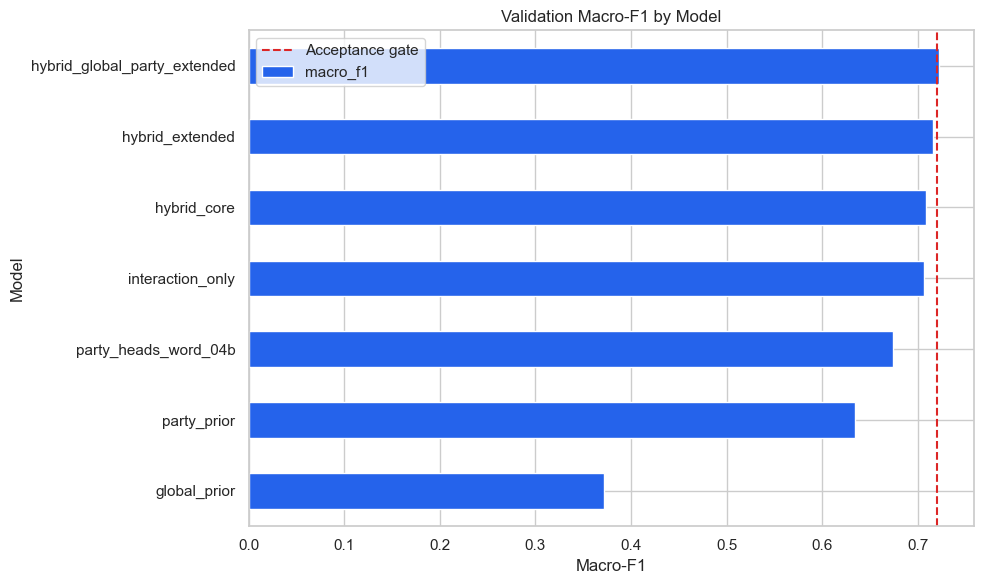

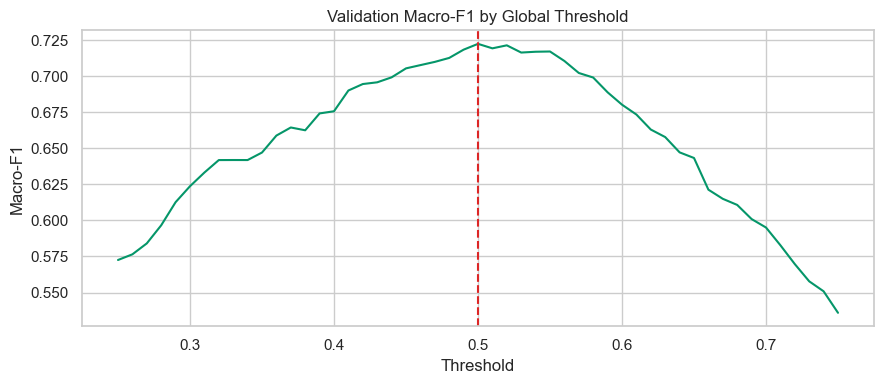

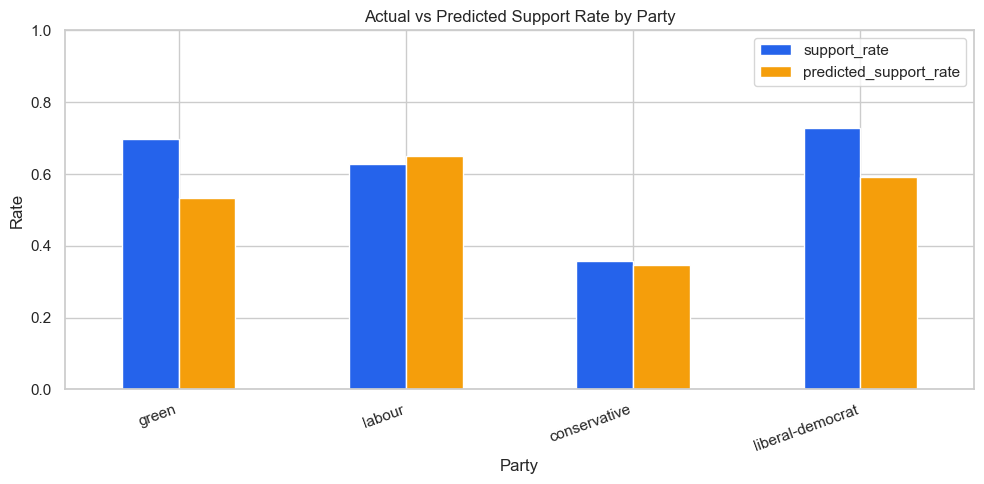

In [10]:
# 比较所有 baseline 和 hybrid 模型。
plot_data = validation_comparison.sort_values('macro_f1')
ax = plot_data['macro_f1'].plot(
    kind='barh', figsize=(10, 6), color='#2563EB'
)
ax.axvline(
    MIN_VALIDATION_MACRO_F1,
    color='#DC2626',
    linestyle='--',
    label='Acceptance gate',
)
ax.set_title('Validation Macro-F1 by Model')
ax.set_xlabel('Macro-F1')
ax.set_ylabel('Model')
ax.legend()
plt.tight_layout()
plt.show()

# 显示全局阈值对 Macro-F1 的影响。
ax = threshold_curve.plot(
    x='threshold', y='macro_f1', figsize=(9, 4), color='#059669', legend=False
)
ax.axvline(selected_threshold, color='#DC2626', linestyle='--')
ax.set_title('Validation Macro-F1 by Global Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Macro-F1')
plt.tight_layout()
plt.show()

# 比较各政党的真实支持率与预测支持率。
rate_plot = validation_party_metrics.set_index('party')[
    ['support_rate', 'predicted_support_rate']
]
ax = rate_plot.plot(kind='bar', figsize=(10, 5), color=['#2563EB', '#F59E0B'])
ax.set_title('Actual vs Predicted Support Rate by Party')
ax.set_xlabel('Party')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

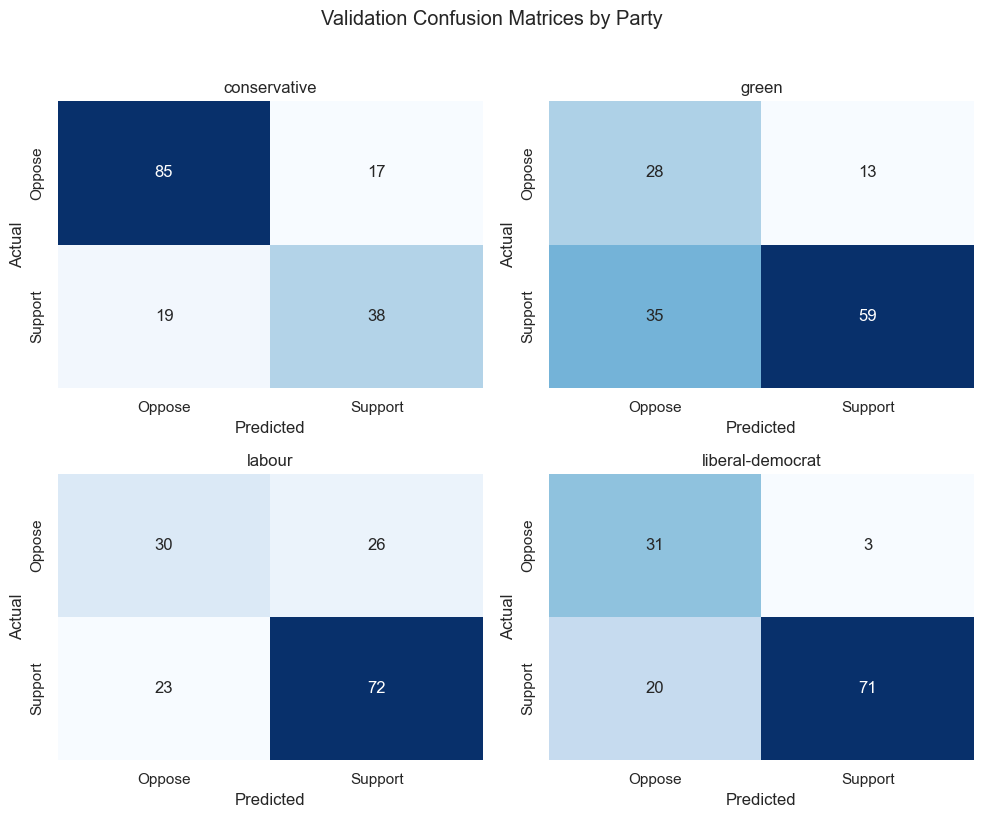

In [11]:
# 为每个政党绘制混淆矩阵。
selected_predictions = (
    selected_validation_probabilities >= selected_threshold
).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, party in zip(axes.ravel(), sorted(validation['party'].unique())):
    mask = validation['party'].eq(party).to_numpy()
    matrix = confusion_matrix(
        y_validation[mask], selected_predictions[mask], labels=[0, 1]
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Oppose', 'Support'],
        yticklabels=['Oppose', 'Support'],
        ax=ax,
    )
    ax.set_title(party)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Validation Confusion Matrices by Party', y=1.02)
plt.tight_layout()
plt.show()

## 10. Save Validation predictions for error analysis

In [12]:
# 保存可定位错误议案的字段，不包含任何 Test 预测。
validation_predictions = validation[[
    'row_id', 'division_key', 'motion_date', 'party',
    'motion_title_clean', 'motion_type', 'motion_family',
    'policy_domain_primary', 'party_role',
    'government_backing_status', 'role_backing_interaction',
    'validation_era', TARGET,
]].copy()
validation_predictions['predicted_support_probability'] = (
    selected_validation_probabilities
)
validation_predictions['predicted_label'] = selected_predictions
validation_predictions['is_correct'] = (
    validation_predictions['predicted_label'].eq(
        validation_predictions[TARGET]
    )
)
validation_predictions.to_csv(
    OUTPUT_DIR / 'hybrid_validation_predictions.csv', index=False
)

error_summary = (
    validation_predictions[~validation_predictions['is_correct']]
    .groupby(['party', 'validation_era', 'policy_domain_primary'], dropna=False)
    .size()
    .rename('errors')
    .reset_index()
    .sort_values('errors', ascending=False)
)
display(error_summary.head(25))

,party,validation_era,policy_domain_primary,errors
19,green,post_2024_election,economy_finance_business,23
34,labour,post_2024_election,economy_finance_business,13
2,conservative,post_2024_election,economy_finance_business,6
51,liberal-democrat,post_2024_election,economy_finance_business,6
42,labour,post_2024_election,transport_infrastructure,5
33,labour,post_2024_election,constitution_democracy_devolution,4
41,labour,post_2024_election,other_or_unclear,4
27,green,post_2024_election,transport_infrastructure,4
36,labour,post_2024_election,employment_labour,4
45,labour,pre_2024_election,economy_finance_business,3


## 11. Optional final Test

只有在 Validation 结果已经讨论并冻结设计后，才能把 `RUN_FINAL_TEST` 改为 `True`。届时会使用 Train+Validation 重新拟合相同架构，再进行一次最终 Test。

In [13]:
test_metrics = None
test_party_metrics = None

if RUN_FINAL_TEST:
    development = pd.concat([train, validation], ignore_index=True)
    development_matrices, test_matrices, final_features = fit_feature_bundle(
        development, test
    )

    if selected_model_name == 'party_heads_word_04b':
        test_probabilities, final_models = fit_separate_party_heads(
            development,
            test,
            final_features['train_word'],
            final_features['eval_word'],
        )
    else:
        selected_c = candidate_settings[selected_model_name]['C']
        final_model = make_classifier(c_value=selected_c)
        final_model.fit(
            development_matrices[selected_model_name],
            development[TARGET].to_numpy(),
        )
        positive_index = list(final_model.classes_).index(1)
        test_probabilities = final_model.predict_proba(
            test_matrices[selected_model_name]
        )[:, positive_index]

    test_metrics = evaluate_probabilities(
        test[TARGET].to_numpy(),
        test_probabilities,
        threshold=selected_threshold,
    )
    test_party_metrics = subgroup_metrics(
        test,
        test_probabilities,
        'party',
        selected_threshold,
    )

    test_predictions = test[[
        'row_id', 'division_key', 'motion_date', 'party',
        'motion_title_clean', TARGET,
    ]].copy()
    test_predictions['predicted_support_probability'] = test_probabilities
    test_predictions['predicted_label'] = (
        test_probabilities >= selected_threshold
    ).astype(int)
    test_predictions.to_csv(
        OUTPUT_DIR / 'hybrid_test_predictions.csv', index=False
    )
    test_party_metrics.to_csv(
        OUTPUT_DIR / 'hybrid_test_party_metrics.csv', index=False
    )

    display(pd.Series(test_metrics, name='test').to_frame())
    display(test_party_metrics.round(3))
else:
    print('Test was not run. Keep RUN_FINAL_TEST=False during development.')

Test was not run. Keep RUN_FINAL_TEST=False during development.


## 12. Summary for review

运行完成后，只需要把下面 Cell 的文本输出发回给我。

In [14]:
summary_lines = [
    '=== HYBRID SUMMARY FOR REVIEW ===',
    f'Selected model: {selected_model_name}',
    f'Validation threshold: {selected_threshold:.2f}',
    f'Validation Macro-F1: {selected_validation_metrics["macro_f1"]:.3f}',
    f'Validation Accuracy: {selected_validation_metrics["accuracy"]:.3f}',
    f'Validation ROC-AUC: {selected_validation_metrics["roc_auc"]:.3f}',
    f'Party-prior Macro-F1: {party_prior_macro_f1:.3f}',
    f'Improvement over party prior: {improvement_over_party_prior:.3f}',
    f'Worst-party Macro-F1: {worst_party_macro_f1:.3f}',
    f'Acceptance gates: {acceptance_checks}',
    f'Next step: {next_step}',
    'Model comparison:',
    validation_comparison[['macro_f1', 'accuracy', 'roc_auc']]
    .round(3).to_string(),
    'Party metrics:',
    validation_party_metrics.round(3).to_string(index=False),
    'Party x 2024 election era metrics:',
    validation_role_metrics.round(3).to_string(index=False),
    f'RUN_FINAL_TEST: {RUN_FINAL_TEST}',
    (
        'Test result: NOT RUN'
        if test_metrics is None
        else f'Test Macro-F1: {test_metrics["macro_f1"]:.3f}'
    ),
    '=== END HYBRID SUMMARY ===',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / 'hybrid_summary.txt', 'w', encoding='utf-8') as file:
    file.write(summary_text)

=== HYBRID SUMMARY FOR REVIEW ===
Selected model: hybrid_global_party_extended
Validation threshold: 0.50
Validation Macro-F1: 0.723
Validation Accuracy: 0.726
Validation ROC-AUC: 0.739
Party-prior Macro-F1: 0.635
Improvement over party prior: 0.088
Worst-party Macro-F1: 0.625
Acceptance gates: {'macro_f1_gate': True, 'party_prior_improvement_gate': True, 'worst_party_gate': True}
Next step: Hybrid validation passes; P2 can be deferred for the MVP.
Model comparison:
                              macro_f1  accuracy  roc_auc
model                                                    
hybrid_global_party_extended     0.723     0.726    0.739
hybrid_extended                  0.716     0.719    0.738
hybrid_core                      0.708     0.714    0.745
interaction_only                 0.706     0.711    0.735
party_heads_word_04b             0.674     0.681    0.720
party_prior                      0.635     0.670    0.641
global_prior                     0.372     0.591    0.500
Party m